# Scene-Specific Neural LOD Threshold Baker - Training Pipeline

**Purpose**: Train an MLP regressor that maps camera pose (position + orientation) to optimal per-scene LOD threshold.

**Input data**: CSV files exported by Unity `BakerOrchestrator`:
- `sample_records.csv` - performance measurements per (point, rotation, LOD level)
- `labels.csv` - oracle-optimal threshold vectors per viewpoint
- `grid_points.csv` - grid point coordinates
- `lod_objects.csv` - baseline LOD object metadata

**Output**: Trained ONNX model + scaler constants JSON for Unity deployment.

**Pipeline stages**:
1. Environment setup and imports
2. Configuration and path validation
3. Data loading and inspection
4. Preprocessing and relabeling with budget
5. Feature engineering with validation
6. Dataset split and DataLoader creation
7. Model architecture definition
8. Training with early stopping
9. Evaluation and metrics
10. ONNX export and verification
11. Deployment guide


## 1. Environment Setup


In [146]:
import sys
import subprocess

import subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn"])

0

Cuda stuff

In [147]:
# gpu issues
# pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121 --force-reinstall

In [148]:
pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121
Note: you may need to restart the kernel to use updated packages.


In [149]:
import os
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
from collections import defaultdict, Counter
import sys

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

# plotting style
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

PyTorch version: 2.5.1+cu121
CUDA available: True
Using device: cuda
NumPy version: 2.4.3
Pandas version: 3.0.1


## 2. Configuration and Path Setup


In [150]:
BASE_DIR = Path('../..').resolve()
DATA_DIR = BASE_DIR / 'data' / 'Baker_2'
MODEL_DIR = BASE_DIR / 'models' / 'baker_2'
PLOTS_DIR = BASE_DIR / 'plots' / 'Stage_2_2' / 'Train'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

SAMPLES_FILE = DATA_DIR / 'sample_records.csv'
LABELS_FILE  = DATA_DIR / 'labels.csv'
GRID_FILE    = DATA_DIR / 'grid_points.csv'
OBJECTS_FILE = DATA_DIR / 'lod_objects.csv'

# hyperparameters
BATCH_SIZE    = 128
LEARNING_RATE = 5e-4
WEIGHT_DECAY  = 1e-4
EPOCHS        = 300
PATIENCE      = 30
HIDDEN_1      = 512
HIDDEN_2      = 256
HIDDEN_3      = 128
DROPOUT       = 0.2
HUBER_DELTA   = 0.15
FEATURE_COUNT = 13
TEST_SPLIT    = 0.2
VAL_SPLIT     = 0.1
RANDOM_SEED   = 42

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f'Data dir:  {DATA_DIR}')
print(f'Model dir: {MODEL_DIR}')
print(f'Plots dir: {PLOTS_DIR}')
print()

# validate input files exist
files_ok = True
for f in [SAMPLES_FILE, LABELS_FILE, GRID_FILE, OBJECTS_FILE]:
    status = 'FOUND' if f.exists() else 'MISSING'
    print(f'  {f.name}: {status}')
    if not f.exists():
        files_ok = False

if not files_ok:
    print("\nERROR: Missing input files. Ensure BakerOrchestrator has exported data.")
    sys.exit(1)

print()
print('Hyperparameters:')
print(f'  BATCH_SIZE={BATCH_SIZE}, LR={LEARNING_RATE}, WEIGHT_DECAY={WEIGHT_DECAY}')
print(f'  HIDDEN={HIDDEN_1}/{HIDDEN_2}/{HIDDEN_3}, DROPOUT={DROPOUT}')
print(f'  HUBER_DELTA={HUBER_DELTA}, PATIENCE={PATIENCE}, EPOCHS={EPOCHS}')
print(f'  FEATURE_COUNT={FEATURE_COUNT}, TEST_SPLIT={TEST_SPLIT}, VAL_SPLIT={VAL_SPLIT}')

Data dir:  C:\Users\Gica\neural-lod\ml_pipeline\data\Baker_2
Model dir: C:\Users\Gica\neural-lod\ml_pipeline\models\baker_2
Plots dir: C:\Users\Gica\neural-lod\ml_pipeline\plots\Stage_2_2\Train

  sample_records.csv: FOUND
  labels.csv: FOUND
  grid_points.csv: FOUND
  lod_objects.csv: FOUND

Hyperparameters:
  BATCH_SIZE=128, LR=0.0005, WEIGHT_DECAY=0.0001
  HIDDEN=512/256/128, DROPOUT=0.2
  HUBER_DELTA=0.15, PATIENCE=30, EPOCHS=300
  FEATURE_COUNT=13, TEST_SPLIT=0.2, VAL_SPLIT=0.1


## 3. Data Loading and Initial Inspection


In [151]:
print("Loading raw data...")
df_samples_raw = pd.read_csv(SAMPLES_FILE)
df_labels_raw = pd.read_csv(LABELS_FILE)
df_grid = pd.read_csv(GRID_FILE)
df_objects = pd.read_csv(OBJECTS_FILE)

print(f"Sample records: {len(df_samples_raw):,} rows")
print(f"Labels: {len(df_labels_raw):,} rows")
print(f"Grid points: {len(df_grid):,} rows")
print(f"LOD objects: {len(df_objects):,} rows")
print()

print("Sample records columns:")
print(list(df_samples_raw.columns))
print("\nFirst 3 sample records:")
print(df_samples_raw.head(3))
print()

print("Labels columns:")
print(list(df_labels_raw.columns))
print("\nFirst 3 labels:")
print(df_labels_raw.head(3))

Loading raw data...
Sample records: 43,200 rows
Labels: 10,800 rows
Grid points: 450 rows
LOD objects: 14,752 rows

Sample records columns:
['point_id', 'rot_x', 'rot_y', 'rot_z', 'lod_level', 'mean_gpu_ms', 'mean_cpu_ms', 'mean_fps', 'triangle_count', 'visible_renderer_count', 'screen_coverage', 'draw_call_count']

First 3 sample records:
   point_id  rot_x  rot_y  rot_z  lod_level  mean_gpu_ms  mean_cpu_ms  \
0         0    -15      0      0          0     5.757480     22.85758   
1         0    -15      0      0          1     5.146309     22.03146   
2         0    -15      0      0          2     4.796279     22.28487   

   mean_fps  triangle_count  visible_renderer_count  screen_coverage  \
0  43.74917         1358678                    6140         0.000348   
1  45.38963          737012                    6146         0.000342   
2  44.87349          456386                    6171         0.000412   

   draw_call_count  
0             4519  
1             4135  
2            

In [152]:
# DIAGNOSTIC + FILTER — remove corrupt GPU readings
# FIX: use df_samples_clean instead of overwriting df_samples_raw
# Overwriting df_samples_raw removed 3 rows and broke the 4:1 ratio in dataset prep
GPU_MAX_VALID_MS = 100.0
df_samples_clean = df_samples_raw[
    (df_samples_raw['mean_gpu_ms'] < 0) |
    (df_samples_raw['mean_gpu_ms'] <= GPU_MAX_VALID_MS)
].copy()

df_diag = df_samples_clean[df_samples_clean['mean_gpu_ms'] > 0]
print(df_diag.groupby('lod_level')['mean_gpu_ms'].describe())
print()
print(f'Rows in df_samples_raw:   {len(df_samples_raw):,}  (never modified)')
print(f'Rows in df_samples_clean: {len(df_samples_clean):,}  (corrupt GPU removed)')
print(f'Overall GPU min:  {df_diag["mean_gpu_ms"].min():.3f}ms')
print(f'Overall GPU max:  {df_diag["mean_gpu_ms"].max():.3f}ms')
print(f'Overall GPU mean: {df_diag["mean_gpu_ms"].mean():.3f}ms')


             count      mean       std       min       25%       50%  \
lod_level                                                              
0          10799.0  5.090554  1.210806  2.388260  4.017408  5.075417   
1          10799.0  4.689286  0.944645  2.367415  3.886454  4.612974   
2          10799.0  4.504228  0.773730  2.396554  3.870793  4.429265   
3          10800.0  3.685821  0.366284  2.329893  3.422596  3.674151   

                75%       max  
lod_level                      
0          6.067533  8.400724  
1          5.443066  7.661686  
2          5.114492  6.806213  
3          3.936098  5.093973  

Rows in df_samples_raw:   43,200  (never modified)
Rows in df_samples_clean: 43,197  (corrupt GPU removed)
Overall GPU min:  2.330ms
Overall GPU max:  8.401ms
Overall GPU mean: 4.492ms


## 4. Data Preprocessing and Relabeling

Recomputes labels from sample_records using frame time budget.
Removes sky-facing poses (extreme pitch angles).
**CORRECTED:** Label parsing handles both scalar and multi-object semicolon-joined formats.


In [ ]:
RUN_RELABELING    = True
RELABEL_BUDGET_MS = 4.5
SKY_PITCH_THRESH  = 45.0

if RUN_RELABELING:
    print(f'Relabeling with budget = {RELABEL_BUDGET_MS}ms (GPU only)...')
    print(f'Filtering sky-facing poses: |rot_x| >= {SKY_PITCH_THRESH}')
    print()

    # FIX: use df_samples_clean (corrupt GPU rows removed)
    # FIX: use GPU time only — CPU is near-constant (scripting bottleneck, not LOD)
    df_samples = df_samples_clean.copy()

    before = len(df_samples)
    df_samples = df_samples[df_samples['rot_x'].abs() < SKY_PITCH_THRESH].copy()
    removed = before - len(df_samples)
    print(f'Removed {removed:,} sky/floor facing rows')
    print()

    lod_levels = sorted(df_samples['lod_level'].unique())
    max_lod    = max(lod_levels)

    obj_thresholds = []
    for _, row in df_objects.iterrows():
        thresh_str = str(row['thresholds'])
        thresholds = [float(v) for v in thresh_str.split(';') if v.strip()]
        obj_thresholds.append(thresholds)

    def get_threshold_vector(optimal_lod):
        result = []
        for obj_thresh in obj_thresholds:
            if optimal_lod < len(obj_thresh):
                result.append(obj_thresh[optimal_lod])
            elif len(obj_thresh) > 0:
                result.append(obj_thresh[-1])
        if not result:
            return [1.0 - (optimal_lod / max_lod)]
        return [sum(result) / len(result)]

    groups = defaultdict(list)
    for _, row in df_samples.iterrows():
        key = (int(row['point_id']), float(row['rot_x']), float(row['rot_y']), float(row['rot_z']))
        groups[key].append(row)

    label_rows     = []
    fallback_count = 0
    lod_dist       = Counter()

    for key, group in groups.items():
        point_id, rot_x, rot_y, rot_z = key
        # sort by LOD ascending
        group_sorted = sorted(group, key=lambda r: int(r['lod_level']))

        # FIX: GPU only — find highest LOD whose GPU time meets budget
        # search from highest LOD down to find most aggressive LOD within budget
        optimal_lod = None
        for rec in group_sorted:  # LOD0 first — find best quality that fits budget
            gpu = float(rec['mean_gpu_ms'])
            if gpu > 0 and gpu <= RELABEL_BUDGET_MS:
                optimal_lod = int(rec['lod_level'])
                break

        if optimal_lod is None:
            # fallback: pick LOD with lowest valid GPU time
            valid = [r for r in group_sorted if float(r['mean_gpu_ms']) > 0]
            if valid:
                best = min(valid, key=lambda r: float(r['mean_gpu_ms']))
            else:
                best = group_sorted[-1]  # last resort
            optimal_lod = int(best['lod_level'])
            fallback_count += 1

        lod_dist[optimal_lod] += 1
        thresh_vec = get_threshold_vector(optimal_lod)
        label_rows.append({
            'point_id':           int(point_id),
            'rot_x':              float(rot_x),
            'rot_y':              float(rot_y),
            'rot_z':              float(rot_z),
            'optimal_thresholds': thresh_vec[0],
            'optimal_lod':        int(optimal_lod)
        })

    df_labels = pd.DataFrame(label_rows)
    df_labels.to_csv(LABELS_FILE, index=False)

    print(f'Labels written: {len(label_rows):,}')
    print(f'Fallbacks: {fallback_count:,} ({100*fallback_count/len(label_rows):.1f}%)')
    print()
    print('LOD distribution:')
    for lod in sorted(lod_dist):
        count = lod_dist[lod]
        pct   = 100 * count / len(label_rows)
        print(f'  LOD {lod}: {count:6,} ({pct:5.1f}%)')
else:
    print('Relabeling skipped.')
    df_samples = df_samples_raw.copy()
    df_labels = df_labels_raw.copy()


Relabeling with budget = 4.5ms (GPU only)...
Filtering sky-facing poses: |rot_x| >= 45.0

Removed 0 sky/floor facing rows

Labels written: 10,800
Fallbacks: 0 (0.0%)

LOD distribution:
  LOD 0:  1,295 ( 12.0%)
  LOD 1:    129 (  1.2%)
  LOD 2:     13 (  0.1%)
  LOD 3:  9,363 ( 86.7%)


Figuring out the budget

In [154]:
# DIAGNOSTIC — find correct RELABEL_BUDGET_MS
df_diag = df_samples_raw[df_samples_raw['mean_gpu_ms'] > 0]
print(df_diag.groupby('lod_level')['mean_gpu_ms'].describe())
print()
print(f"Overall GPU min:  {df_diag['mean_gpu_ms'].min():.3f}ms")
print(f"Overall GPU max:  {df_diag['mean_gpu_ms'].max():.3f}ms")
print(f"Overall GPU mean: {df_diag['mean_gpu_ms'].mean():.3f}ms")

             count          mean           std       min       25%       50%  \
lod_level                                                                      
0          10800.0  8.130293e+07  8.449248e+09  2.388260  4.017463  5.075437   
1          10800.0  1.263966e+07  1.313552e+09  2.367415  3.886523  4.612996   
2          10800.0  5.509262e+07  5.725392e+09  2.396554  3.870830  4.429331   
3          10800.0  3.685821e+00  3.662838e-01  2.329893  3.422596  3.674151   

                75%           max  
lod_level                          
0          6.067825  8.780716e+11  
1          5.443232  1.365083e+11  
2          5.114563  5.950002e+11  
3          3.936098  5.093973e+00  

Overall GPU min:  2.330ms
Overall GPU max:  878071600000.000ms
Overall GPU mean: 37258803.103ms


### Visualization: Label Distribution


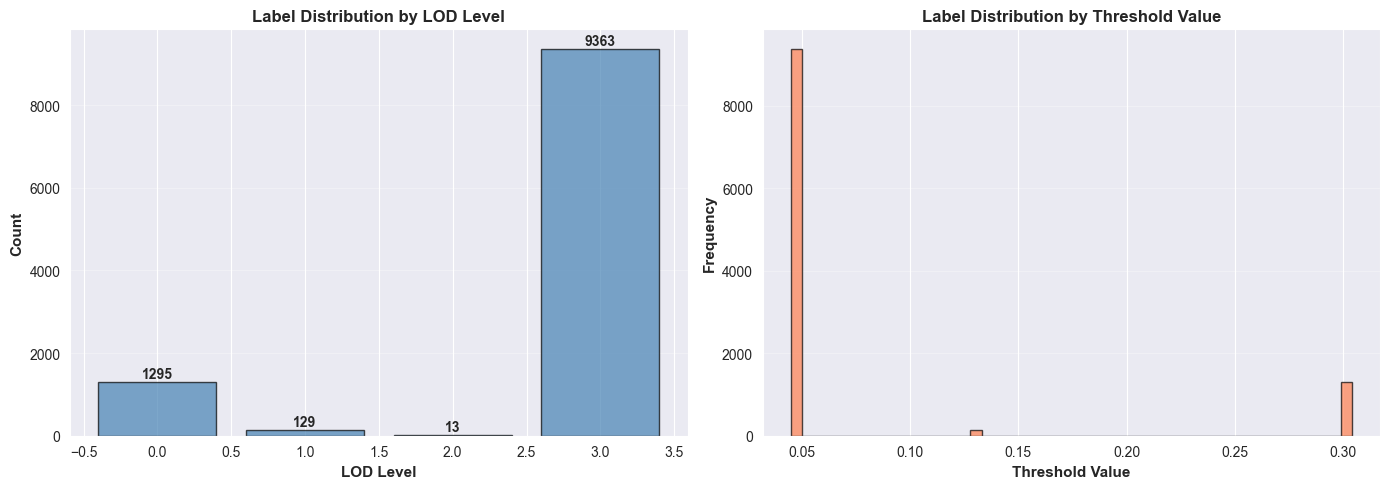

Label statistics:
  Mean threshold: 0.0771
  Std threshold:  0.0843
  Min threshold:  0.0450
  Max threshold:  0.3041


In [155]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LOD distribution histogram
lod_counts = df_labels['optimal_lod'].value_counts().sort_index()
axes[0].bar(lod_counts.index, lod_counts.values, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('LOD Level', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=11, fontweight='bold')
axes[0].set_title('Label Distribution by LOD Level', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(lod_counts.values):
    axes[0].text(lod_counts.index[i], v + 100, str(v), ha='center', fontweight='bold')

# Threshold distribution histogram
axes[1].hist(df_labels['optimal_thresholds'], bins=50, color='coral', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Threshold Value', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[1].set_title('Label Distribution by Threshold Value', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'viz_01_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Label statistics:")
print(f"  Mean threshold: {df_labels['optimal_thresholds'].mean():.4f}")
print(f"  Std threshold:  {df_labels['optimal_thresholds'].std():.4f}")
print(f"  Min threshold:  {df_labels['optimal_thresholds'].min():.4f}")
print(f"  Max threshold:  {df_labels['optimal_thresholds'].max():.4f}")

## 5. Feature Engineering and Validation

**CORRECTED:** Explicit feature order validation. Ensures feature column sequence matches LODThresholdPredictor.cs exactly.


In [156]:
print('Feature Engineering...')
print()

FEATURE_COLS = [
    'pos_x', 'pos_y', 'pos_z',
    'sin_pitch', 'cos_pitch',
    'sin_yaw', 'cos_yaw',
    'sin_roll', 'cos_roll',
    'triangle_count', 'visible_renderer_count',
    'screen_coverage', 'draw_call_count'
]

print(f'Expected features ({len(FEATURE_COLS)}):')
for i, col in enumerate(FEATURE_COLS, 1):
    print(f'  {i:2d}. {col}')
print()

# FIX: use df_samples_raw (full 43200 rows) for feature engineering
# df_samples_clean has 3 rows removed which breaks the 4:1 alignment with labels
df_feat_src = df_samples_raw.copy()

df_features_raw = df_feat_src[['point_id', 'rot_x', 'rot_y', 'rot_z']].copy()
df_features_raw['pos_x'] = df_features_raw['point_id'].map(
    dict(zip(df_grid['point_id'], df_grid['x']))
)
df_features_raw['pos_y'] = df_features_raw['point_id'].map(
    dict(zip(df_grid['point_id'], df_grid['y']))
)
df_features_raw['pos_z'] = df_features_raw['point_id'].map(
    dict(zip(df_grid['point_id'], df_grid['z']))
)

pitch_rad = np.radians(df_features_raw['rot_x'])
yaw_rad   = np.radians(df_features_raw['rot_y'])
roll_rad  = np.radians(df_features_raw['rot_z'])

df_features_raw['sin_pitch'] = np.sin(pitch_rad)
df_features_raw['cos_pitch'] = np.cos(pitch_rad)
df_features_raw['sin_yaw']   = np.sin(yaw_rad)
df_features_raw['cos_yaw']   = np.cos(yaw_rad)
df_features_raw['sin_roll']  = np.sin(roll_rad)
df_features_raw['cos_roll']  = np.cos(roll_rad)

df_features_raw['triangle_count']         = df_feat_src['triangle_count'].values
df_features_raw['visible_renderer_count'] = df_feat_src['visible_renderer_count'].values
df_features_raw['screen_coverage']        = df_feat_src['screen_coverage'].values
df_features_raw['draw_call_count']        = df_feat_src['draw_call_count'].values

df_features = df_features_raw[FEATURE_COLS].copy()

print(f'Feature matrix shape: {df_features.shape}')
print(f'Feature columns ({len(df_features.columns)}):')
for i, col in enumerate(df_features.columns, 1):
    print(f'  {i:2d}. {col:25s} min={df_features[col].min():10.4f} max={df_features[col].max():10.4f} mean={df_features[col].mean():10.4f}')
print()

nan_count = df_features.isna().sum().sum()
if nan_count > 0:
    print(f'WARNING: {nan_count} NaN values in feature matrix — dropping rows')
    df_features = df_features.dropna()
else:
    print('✓ No NaN values in feature matrix')

print()
print(f'Label shape: {len(df_labels)}')
print(f'Label range: [{df_labels["optimal_thresholds"].min():.4f}, {df_labels["optimal_thresholds"].max():.4f}]')
print()
print('✓ Feature engineering complete')


Feature Engineering...

Expected features (13):
   1. pos_x
   2. pos_y
   3. pos_z
   4. sin_pitch
   5. cos_pitch
   6. sin_yaw
   7. cos_yaw
   8. sin_roll
   9. cos_roll
  10. triangle_count
  11. visible_renderer_count
  12. screen_coverage
  13. draw_call_count

Feature matrix shape: (43200, 13)
Feature columns (13):
   1. pos_x                     min=  -48.1667 max=   45.1667 mean=   -1.5000
   2. pos_y                     min=    1.8000 max=   11.8081 mean=    4.5817
   3. pos_z                     min=  -44.4667 max=   48.8667 mean=    2.2000
   4. sin_pitch                 min=   -0.2588 max=    0.2588 mean=    0.0000
   5. cos_pitch                 min=    0.9659 max=    1.0000 mean=    0.9773
   6. sin_yaw                   min=   -1.0000 max=    1.0000 mean=    0.0000
   7. cos_yaw                   min=   -1.0000 max=    1.0000 mean=   -0.0000
   8. sin_roll                  min=    0.0000 max=    0.0000 mean=    0.0000
   9. cos_roll                  min=    1.0000 max=

### Visualization: Feature Statistics


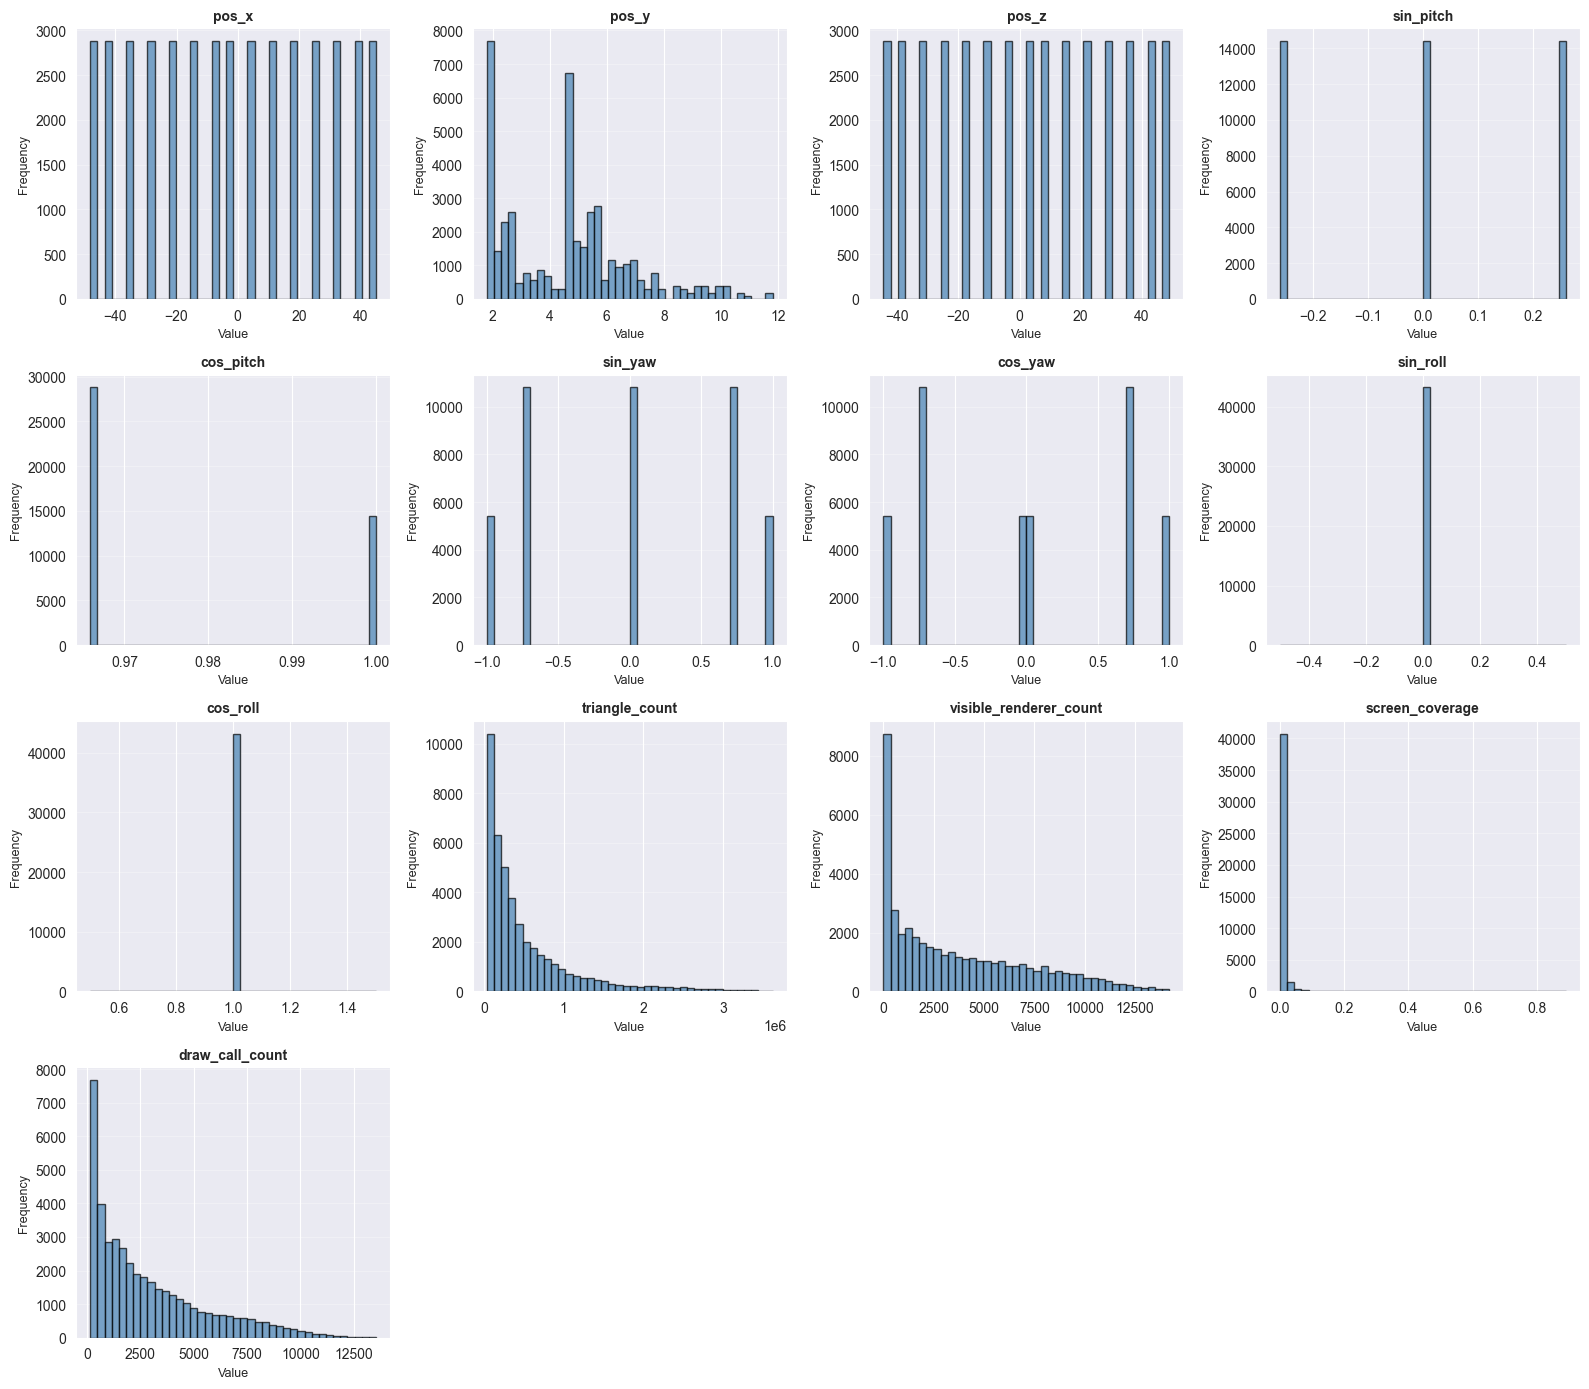

Feature distribution plots saved.


In [157]:
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for idx, col in enumerate(FEATURE_COLS):
    ax = axes[idx]
    ax.hist(df_features[col], bins=40, color='steelblue', alpha=0.7, edgecolor='black')
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('Value', fontsize=9)
    ax.set_ylabel('Frequency', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

# Hide unused subplots
for idx in range(len(FEATURE_COLS), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'viz_02_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("Feature distribution plots saved.")

## 6. Dataset Preparation and Splitting


In [158]:
print('Preparing dataset...')
print()

# FIX: group by actual viewpoint key instead of fragile index arithmetic
# Previous approach: index // 4 broke when 3 rows were removed by GPU filter
# Correct approach: take only LOD0 rows — one row per (point_id, rotation)
# LOD0 rows carry the pose features we need; LOD level itself is not a feature
BIAS_COLS = [c for c in df_features.columns if 'bias' in c.lower() or 'lod' in c.lower()]
if BIAS_COLS:
    print(f'Dropping bias-related columns: {BIAS_COLS}')
df_features_pose = df_features.drop(columns=BIAS_COLS).copy()

# Add lod_level back temporarily to filter LOD0 rows
df_features_pose['_lod'] = df_samples_raw['lod_level'].values
df_lod0 = df_features_pose[df_features_pose['_lod'] == 0].drop(columns=['_lod']).reset_index(drop=True)

print(f'LOD0 rows (one per viewpoint): {len(df_lod0):,}')
print(f'Labels:                        {len(df_labels):,}')

assert len(df_lod0) == len(df_labels), \
    f'Mismatch: {len(df_lod0)} LOD0 rows vs {len(df_labels)} labels'

X = df_lod0.values.astype(np.float32)
y = df_labels['optimal_thresholds'].values.astype(np.float32)

print(f'X shape: {X.shape} (samples, features)')
print(f'y shape: {y.shape}')
print()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Scaler mean:  {scaler.mean_}')
print(f'Scaler scale: {scaler.scale_}')
print()

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_scaled, y, test_size=TEST_SPLIT, random_state=RANDOM_SEED
)

val_size = VAL_SPLIT / (1 - TEST_SPLIT)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=val_size, random_state=RANDOM_SEED
)

print(f'Train set: {X_train.shape[0]:,} samples ({100*X_train.shape[0]/len(X):.1f}%)')
print(f'Val set:   {X_val.shape[0]:,} samples ({100*X_val.shape[0]/len(X):.1f}%)')
print(f'Test set:  {X_test.shape[0]:,} samples ({100*X_test.shape[0]/len(X):.1f}%)')
print()

class ThresholdDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float().unsqueeze(1)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = ThresholdDataset(X_train, y_train)
val_dataset   = ThresholdDataset(X_val,   y_val)
test_dataset  = ThresholdDataset(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train loader: {len(train_loader)} batches')
print(f'Val loader:   {len(val_loader)} batches')
print(f'Test loader:  {len(test_loader)} batches')


Preparing dataset...

LOD0 rows (one per viewpoint): 10,800
Labels:                        10,800
X shape: (10800, 13) (samples, features)
y shape: (10800,)

Scaler mean:  [-1.50000153e+00  4.58165931e+00  2.19999925e+00  0.00000000e+00
  9.77283875e-01  0.00000000e+00 -2.63163976e-17  0.00000000e+00
  1.00000000e+00  1.06006704e+06  3.72867361e+03  6.52801732e-03
  3.72660352e+03]
Scaler scale: [2.88032905e+01 2.21887067e+00 2.88032931e+01 2.11324864e-01
 1.60627259e-02 7.07106775e-01 7.07106775e-01 1.00000000e+00
 1.00000000e+00 8.83358331e+05 3.48609401e+03 2.68596939e-02
 3.13597013e+03]

Train set: 7,560 samples (70.0%)
Val set:   1,080 samples (10.0%)
Test set:  2,160 samples (20.0%)

Train loader: 60 batches
Val loader:   9 batches
Test loader:  17 batches


### Visualization: Dataset Split


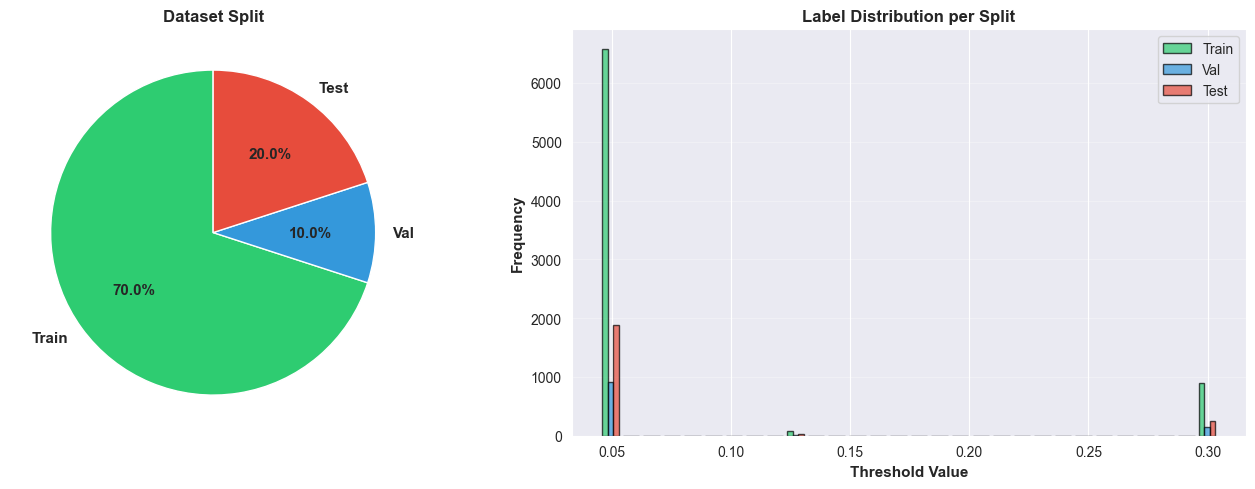

In [159]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Split size pie chart
split_sizes = [X_train.shape[0], X_val.shape[0], X_test.shape[0]]
split_labels = ['Train', 'Val', 'Test']
colors = ['#2ecc71', '#3498db', '#e74c3c']
axes[0].pie(split_sizes, labels=split_labels, autopct='%1.1f%%', colors=colors, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[0].set_title('Dataset Split', fontsize=12, fontweight='bold')

# Target label distribution per split
axes[1].hist([y_train, y_val, y_test], bins=30, label=split_labels, color=colors, alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Threshold Value', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[1].set_title('Label Distribution per Split', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'viz_03_dataset_split.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Model Architecture


In [160]:
INPUT_DIM = FEATURE_COUNT
OUTPUT_DIM = 1

class ThresholdMLP(nn.Module):
    def __init__(self, input_dim, hidden_1, hidden_2, hidden_3, output_dim, dropout=0.2):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_1)
        self.bn1 = nn.BatchNorm1d(hidden_1)
        self.drop1 = nn.Dropout(dropout)

        self.fc2 = nn.Linear(hidden_1, hidden_2)
        self.bn2 = nn.BatchNorm1d(hidden_2)
        self.drop2 = nn.Dropout(dropout)

        self.fc3 = nn.Linear(hidden_2, hidden_3)
        self.bn3 = nn.BatchNorm1d(hidden_3)
        self.drop3 = nn.Dropout(dropout)

        self.fc4 = nn.Linear(hidden_3, output_dim)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = torch.relu(x)
        x = self.drop1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = torch.relu(x)
        x = self.drop2(x)

        x = self.fc3(x)
        x = self.bn3(x)
        x = torch.relu(x)
        x = self.drop3(x)

        x = self.fc4(x)
        x = self.sigmoid(x)
        return x

model = ThresholdMLP(
    input_dim=INPUT_DIM,
    hidden_1=HIDDEN_1,
    hidden_2=HIDDEN_2,
    hidden_3=HIDDEN_3,
    output_dim=OUTPUT_DIM,
    dropout=DROPOUT
)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print()
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

ThresholdMLP(
  (fc1): Linear(in_features=13, out_features=512, bias=True)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop1): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop2): Dropout(p=0.2, inplace=False)
  (fc3): Linear(in_features=256, out_features=128, bias=True)
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop3): Dropout(p=0.2, inplace=False)
  (fc4): Linear(in_features=128, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

Total parameters: 173,313
Trainable parameters: 173,313


## 8. Training with Early Stopping


In [161]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No CUDA GPU")

True
NVIDIA GeForce RTX 3080 Laptop GPU


In [162]:
criterion = nn.HuberLoss(delta=HUBER_DELTA)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10
)
best_val_loss = float('inf')
best_model_path = MODEL_DIR / 'baker_best_model.pt'
patience_counter = 0

train_losses = []
val_losses = []
learning_rates = []

print("Training...")
print(f"Device: {device}")
print()

for epoch in range(EPOCHS):
    # Training
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * X_batch.size(0)

    train_loss /= len(train_dataset)
    train_losses.append(train_loss)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            val_loss += loss.item() * X_batch.size(0)

    val_loss /= len(val_dataset)
    val_losses.append(val_loss)

    current_lr = optimizer.param_groups[0]['lr']
    learning_rates.append(current_lr)

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | Train loss: {train_loss:.6f} | Val loss: {val_loss:.6f} | LR: {current_lr:.2e}")

    # Early stopping with checkpoint
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        patience_counter += 1

    scheduler.step(val_loss)

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

print()
print("Training complete.")
print(f"Best validation loss: {best_val_loss:.6f}")

# Load best model
model.load_state_dict(torch.load(best_model_path))
model.eval()

Training...
Device: cuda

Epoch  20/300 | Train loss: 0.001504 | Val loss: 0.001925 | LR: 2.50e-04
Epoch  40/300 | Train loss: 0.001385 | Val loss: 0.001825 | LR: 2.50e-04
Epoch  60/300 | Train loss: 0.001421 | Val loss: 0.001731 | LR: 2.50e-04
Epoch  80/300 | Train loss: 0.001350 | Val loss: 0.001714 | LR: 1.25e-04

Early stopping at epoch 89

Training complete.
Best validation loss: 0.001610


ThresholdMLP(
  (fc1): Linear(in_features=13, out_features=512, bias=True)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop1): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop2): Dropout(p=0.2, inplace=False)
  (fc3): Linear(in_features=256, out_features=128, bias=True)
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop3): Dropout(p=0.2, inplace=False)
  (fc4): Linear(in_features=128, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

### Visualization: Training Curves


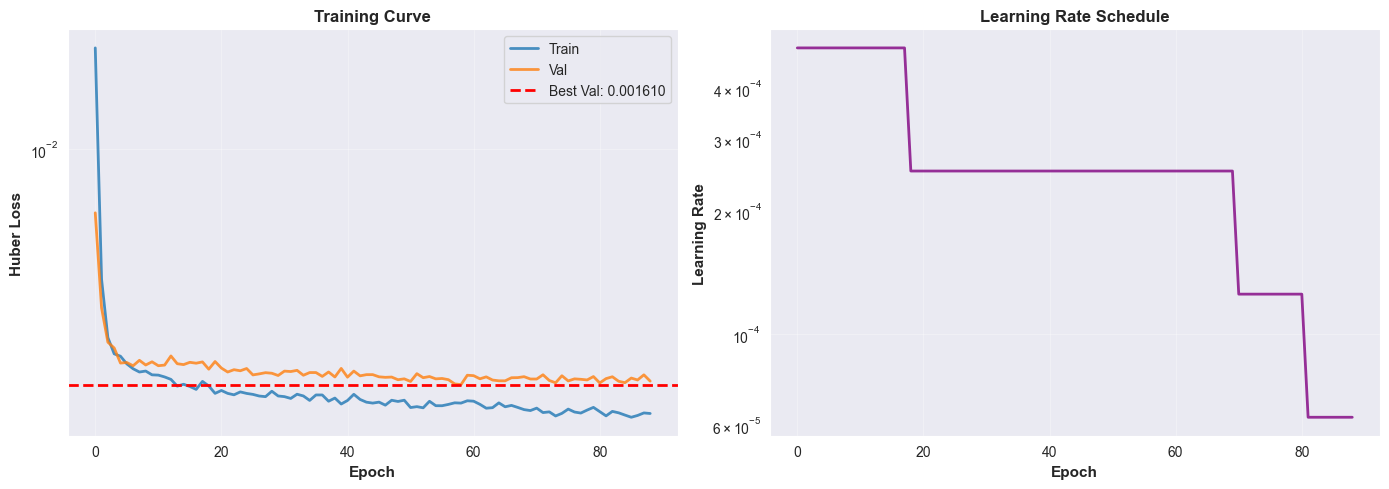

In [163]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(train_losses, label='Train', linewidth=2, alpha=0.8)
axes[0].plot(val_losses, label='Val', linewidth=2, alpha=0.8)
axes[0].axhline(y=best_val_loss, color='red', linestyle='--', linewidth=2, label=f'Best Val: {best_val_loss:.6f}')
axes[0].set_xlabel('Epoch', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Huber Loss', fontsize=11, fontweight='bold')
axes[0].set_title('Training Curve', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)
axes[0].set_yscale('log')

# Learning rate schedule
axes[1].semilogy(learning_rates, linewidth=2, color='purple', alpha=0.8)
axes[1].set_xlabel('Epoch', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Learning Rate', fontsize=11, fontweight='bold')
axes[1].set_title('Learning Rate Schedule', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'viz_04_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Evaluation and Metrics


In [164]:
print("Evaluating on test set...")
print()

y_train_pred = []
y_train_true = []
with torch.no_grad():
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_pred = model(X_batch).cpu().numpy().flatten()
        y_train_pred.extend(y_pred)
        y_train_true.extend(y_batch.numpy().flatten())

y_train_pred = np.array(y_train_pred)
y_train_true = np.array(y_train_true)

y_val_pred = []
y_val_true = []
with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        y_pred = model(X_batch).cpu().numpy().flatten()
        y_val_pred.extend(y_pred)
        y_val_true.extend(y_batch.numpy().flatten())

y_val_pred = np.array(y_val_pred)
y_val_true = np.array(y_val_true)

y_test_pred = []
y_test_true = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_pred = model(X_batch).cpu().numpy().flatten()
        y_test_pred.extend(y_pred)
        y_test_true.extend(y_batch.numpy().flatten())

y_test_pred = np.array(y_test_pred)
y_test_true = np.array(y_test_true)

# Metrics
train_mae = mean_absolute_error(y_train_true, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train_true, y_train_pred))
val_mae = mean_absolute_error(y_val_true, y_val_pred)
val_rmse = np.sqrt(mean_squared_error(y_val_true, y_val_pred))
test_mae = mean_absolute_error(y_test_true, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test_true, y_test_pred))

print("Metrics:")
print(f"  Train MAE:  {train_mae:.4f}")
print(f"  Train RMSE: {train_rmse:.4f}")
print(f"  Val MAE:    {val_mae:.4f}")
print(f"  Val RMSE:   {val_rmse:.4f}")
print(f"  Test MAE:   {test_mae:.4f}")
print(f"  Test RMSE:  {test_rmse:.4f}")

overall_mae = test_mae
overall_rmse = test_rmse

Evaluating on test set...

Metrics:
  Train MAE:  0.0224
  Train RMSE: 0.0471
  Val MAE:    0.0285
  Val RMSE:   0.0588
  Test MAE:   0.0240
  Test RMSE:  0.0511


### Visualization: Predictions vs Ground Truth


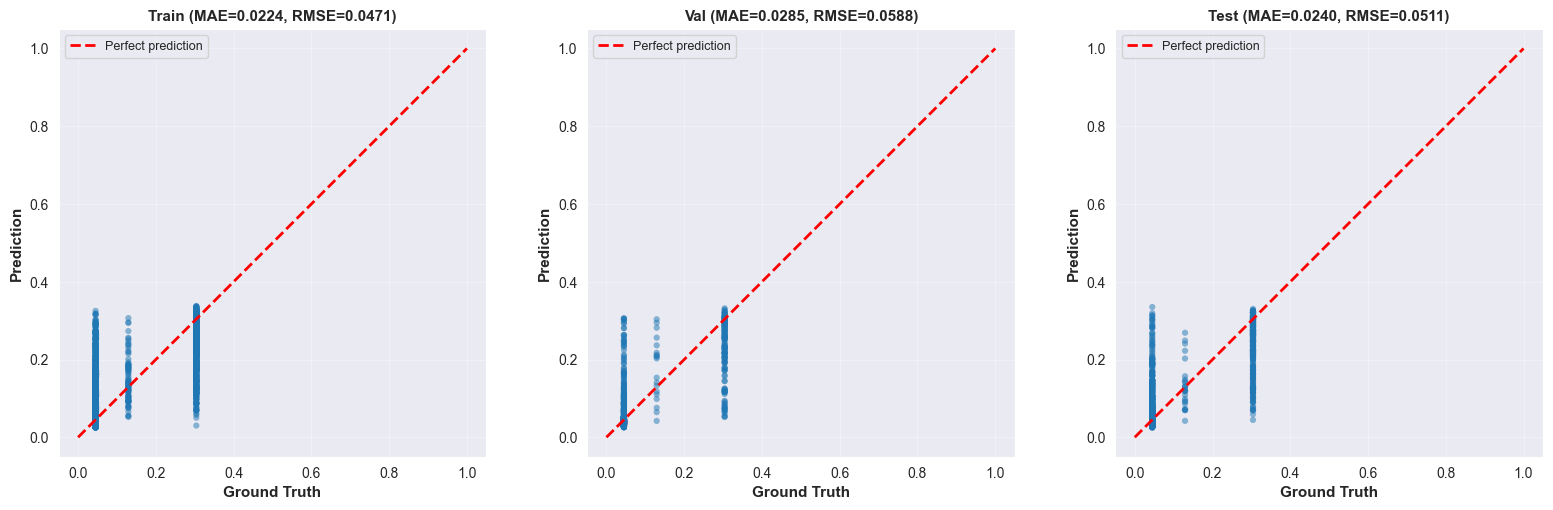

In [165]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

splits = [
    ('Train', y_train_true, y_train_pred, train_mae, train_rmse),
    ('Val', y_val_true, y_val_pred, val_mae, val_rmse),
    ('Test', y_test_true, y_test_pred, test_mae, test_rmse)
]

for idx, (split_name, y_true, y_pred, mae, rmse) in enumerate(splits):
    ax = axes[idx]
    ax.scatter(y_true, y_pred, alpha=0.5, s=20, edgecolors='none')
    ax.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect prediction')
    ax.set_xlabel('Ground Truth', fontsize=11, fontweight='bold')
    ax.set_ylabel('Prediction', fontsize=11, fontweight='bold')
    ax.set_title(f'{split_name} (MAE={mae:.4f}, RMSE={rmse:.4f})', fontsize=11, fontweight='bold')
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_aspect('equal')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'viz_05_predictions_vs_truth.png', dpi=150, bbox_inches='tight')
plt.show()

### Visualization: Residuals and Error Distribution


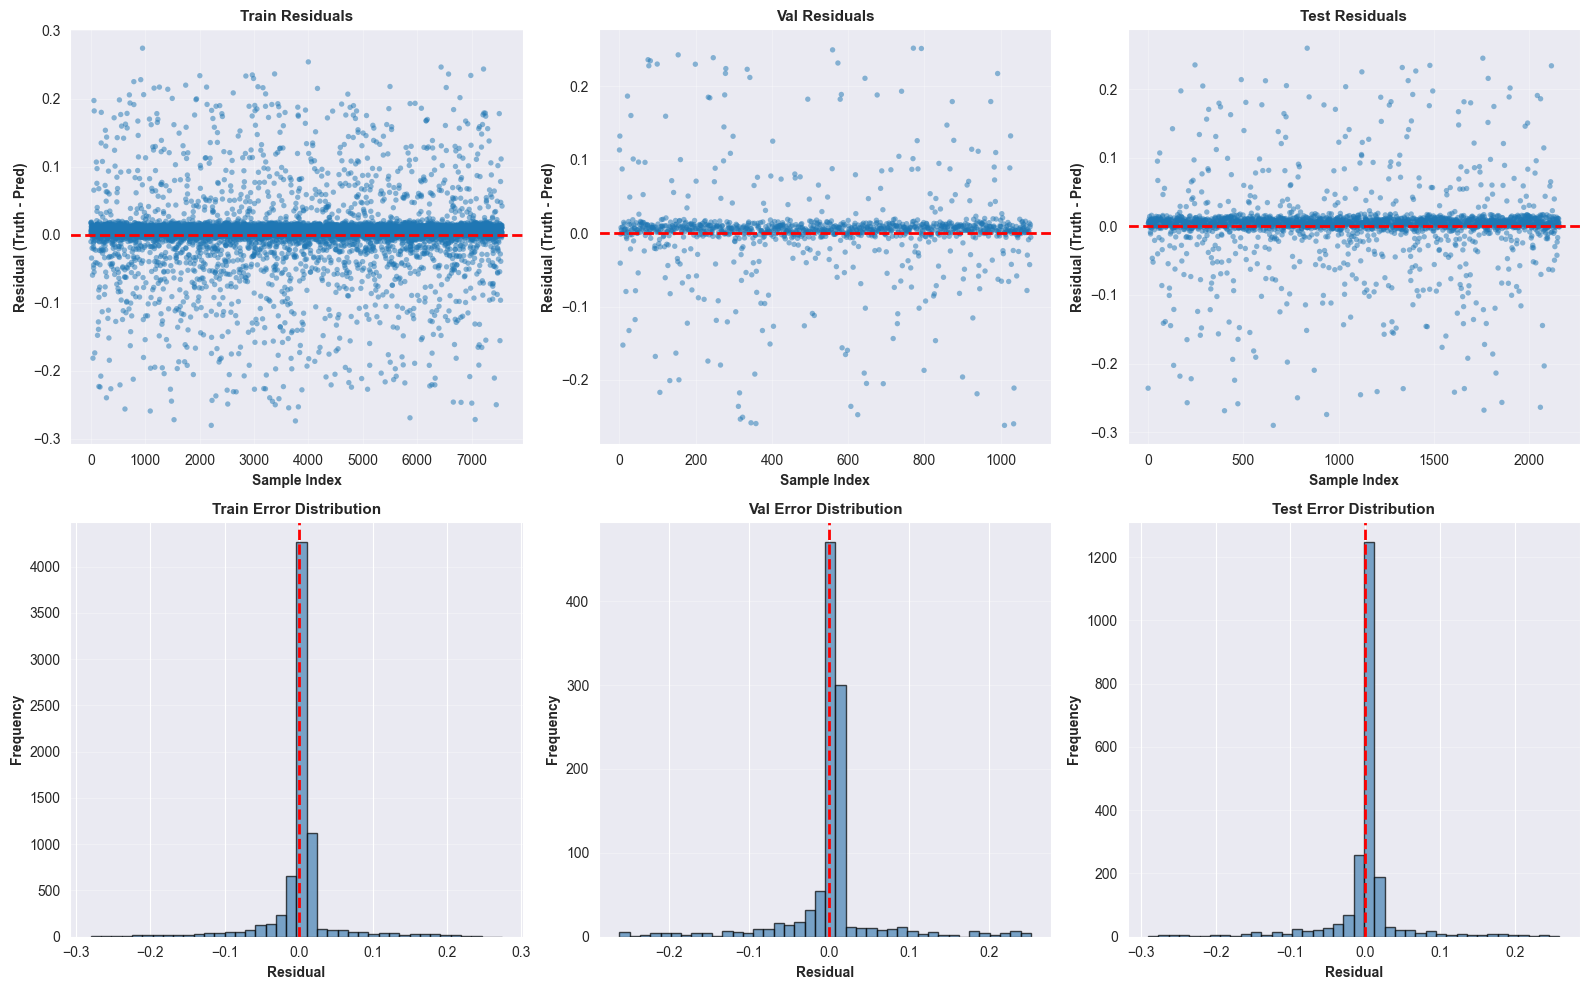

In [166]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

splits = [
    ('Train', y_train_true, y_train_pred),
    ('Val', y_val_true, y_val_pred),
    ('Test', y_test_true, y_test_pred)
]

for idx, (split_name, y_true, y_pred) in enumerate(splits):
    residuals = y_true - y_pred

    # Residuals over samples
    ax = axes[0, idx]
    ax.scatter(range(len(residuals)), residuals, alpha=0.5, s=15, edgecolors='none')
    ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
    ax.set_xlabel('Sample Index', fontsize=10, fontweight='bold')
    ax.set_ylabel('Residual (Truth - Pred)', fontsize=10, fontweight='bold')
    ax.set_title(f'{split_name} Residuals', fontsize=11, fontweight='bold')
    ax.grid(alpha=0.3)

    # Residual distribution
    ax = axes[1, idx]
    ax.hist(residuals, bins=40, color='steelblue', alpha=0.7, edgecolor='black')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2)
    ax.set_xlabel('Residual', fontsize=10, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=10, fontweight='bold')
    ax.set_title(f'{split_name} Error Distribution', fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'viz_06_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. ONNX Export and Verification


In [167]:
print("Exporting to ONNX...")
print()

model.eval()
model.cpu()

dummy_input = torch.zeros(1, INPUT_DIM, dtype=torch.float32)
onnx_path = MODEL_DIR / "lod_baker.onnx"

torch.onnx.export(
    model,
    dummy_input,
    str(onnx_path),
    export_params=True,
    opset_version=15,
    input_names=["features"],
    output_names=["thresholds"],
    dynamic_axes={
        "features":   {0: "batch_size"},
        "thresholds": {0: "batch_size"}
    }
)

print(f"✓ ONNX model exported to {onnx_path}")

# Verify ONNX model
try:
    import onnx
    onnx_model = onnx.load(str(onnx_path))
    onnx.checker.check_model(onnx_model)
    print("✓ ONNX model verification: PASSED")
    print(f"  Inputs:  {[i.name for i in onnx_model.graph.input]}")
    print(f"  Outputs: {[o.name for o in onnx_model.graph.output]}")
except ImportError:
    print("Note: onnx package not installed, skipping verification")
except Exception as e:
    print(f"WARNING: ONNX verification failed: {e}")

Exporting to ONNX...

✓ ONNX model exported to C:\Users\Gica\neural-lod\ml_pipeline\models\baker_2\lod_baker.onnx
✓ ONNX model verification: PASSED
  Inputs:  ['features']
  Outputs: ['thresholds']


## 11. Scaler Export


In [168]:
print("Exporting scaler constants...")
print()

scaler_dict = {
    'feature_names': FEATURE_COLS,
    'mean': scaler.mean_.tolist(),
    'scale': scaler.scale_.tolist()
}

scaler_path = MODEL_DIR / 'baker_scaler_constants.json'
with open(str(scaler_path), 'w') as f:
    json.dump(scaler_dict, f, indent=2)

print(f"✓ Scaler constants exported to {scaler_path}")
print()
print("Scaler contents:")
print(json.dumps(scaler_dict, indent=2))

Exporting scaler constants...

✓ Scaler constants exported to C:\Users\Gica\neural-lod\ml_pipeline\models\baker_2\baker_scaler_constants.json

Scaler contents:
{
  "feature_names": [
    "pos_x",
    "pos_y",
    "pos_z",
    "sin_pitch",
    "cos_pitch",
    "sin_yaw",
    "cos_yaw",
    "sin_roll",
    "cos_roll",
    "triangle_count",
    "visible_renderer_count",
    "screen_coverage",
    "draw_call_count"
  ],
  "mean": [
    -1.5000015258789063,
    4.581659308274587,
    2.1999992529551187,
    0.0,
    0.9772838751475016,
    0.0,
    -2.6316397620744452e-17,
    0.0,
    1.0,
    1060067.0406481482,
    3728.6736111111113,
    0.006528017321923775,
    3726.6035185185187
  ],
  "scale": [
    28.803290467415678,
    2.2188706705455266,
    28.803293116208206,
    0.21132486420804086,
    0.01606272592548186,
    0.707106775135739,
    0.707106775135739,
    1.0,
    1.0,
    883358.330504407,
    3486.0940068346995,
    0.02685969385588214,
    3135.9701327864013
  ]
}


## 12. Deployment Instructions


In [169]:
print("="*60)
print("TRAINING COMPLETE - DEPLOYMENT CHECKLIST")
print("="*60)
print()
print("Files to copy to Unity project:")
print()
print("  1. lod_baker.onnx")
print(f"     From: {MODEL_DIR / 'lod_baker.onnx'}")
print("     To:   Assets/StreamingAssets/")
print()
print("  2. baker_scaler_constants.json")
print(f"     From: {MODEL_DIR / 'baker_scaler_constants.json'}")
print("     To:   Assets/StreamingAssets/")
print()
print("Unity Configuration:")
print()
print("  LODThresholdPredictor.cs:")
print("    - onnxAsset: Drag lod_baker.onnx (imported as ModelAsset)")
print("    - scalerJsonFileName: 'baker_scaler_constants.json'")
print()
print("  InferenceEvaluationLogger.cs:")
print("    - Attach to same GameObject as LODThresholdPredictor")
print("    - Enable autoStart to begin logging on Play")
print()
print("Runtime Feature Vector:")
print()
for i, col in enumerate(FEATURE_COLS, 1):
    print(f"  {i:2d}. {col:25s} (normalized using scaler JSON)")
print()
print("Model Output:")
print(f"  Single scalar in [0, 1]: optimal threshold for the scene")
print()
print("Training Summary:")
print(f"  Input features:       {INPUT_DIM}")
print(f"  Output dimension:     {OUTPUT_DIM}")
print(f"  Model parameters:     {total_params:,}")
print(f"  Best validation loss: {best_val_loss:.6f}")
print(f"  Test MAE:             {overall_mae:.4f}")
print(f"  Test RMSE:            {overall_rmse:.4f}")
print()
print(f"ONNX size: {os.path.getsize(onnx_path) / 1024:.1f} KB")
print()
print("All output files:")
for f in sorted(MODEL_DIR.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:40s} ({size_kb:8.1f} KB)")

TRAINING COMPLETE - DEPLOYMENT CHECKLIST

Files to copy to Unity project:

  1. lod_baker.onnx
     From: C:\Users\Gica\neural-lod\ml_pipeline\models\baker_2\lod_baker.onnx
     To:   Assets/StreamingAssets/

  2. baker_scaler_constants.json
     From: C:\Users\Gica\neural-lod\ml_pipeline\models\baker_2\baker_scaler_constants.json
     To:   Assets/StreamingAssets/

Unity Configuration:

  LODThresholdPredictor.cs:
    - onnxAsset: Drag lod_baker.onnx (imported as ModelAsset)
    - scalerJsonFileName: 'baker_scaler_constants.json'

  InferenceEvaluationLogger.cs:
    - Attach to same GameObject as LODThresholdPredictor
    - Enable autoStart to begin logging on Play

Runtime Feature Vector:

   1. pos_x                     (normalized using scaler JSON)
   2. pos_y                     (normalized using scaler JSON)
   3. pos_z                     (normalized using scaler JSON)
   4. sin_pitch                 (normalized using scaler JSON)
   5. cos_pitch                 (normalized usi